SRAPING DATA

In [14]:
pip install yfinance pandas matplotlib


In [15]:
# Instal pustaka yang dibutuhkan
!pip install yfinance pandas openpyxl matplotlib --quiet

# Import
import yfinance as yf
import pandas as pd
import datetime as dt

# Ambil data BBCA
ticker = "BBCA.JK"
start_date = "2015-01-01"
end_date = dt.date.today().strftime("%Y-%m-%d")

print(f"Mengunduh data {ticker} dari {start_date} sampai {end_date} ...")
data = yf.download(ticker, start=start_date, end=end_date, interval="1d", auto_adjust=True)

# Simpan ke file Excel
file_path = "/content/Data_BBCA_2015_sampai_sekarang.xlsx"
data.to_excel(file_path)
print(f"\n✅ File berhasil disimpan: {file_path}")

# Buat tombol download
from google.colab import files
files.download(file_path)


[*********************100%***********************]  1 of 1 completed

Mengunduh data BBCA.JK dari 2015-01-01 sampai 2025-10-15 ...



✅ File berhasil disimpan: /content/Data_BBCA_2015_sampai_sekarang.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Data Harga Saham BBCA
(forecasting)

Forecasing harga saham BBCA

Kolom tersedia: ['Price', 'Close', 'High', 'Low', 'Open', 'Volume']


C:\Users\Aditya P J\AppData\Local\Temp\ipykernel_21736\1917571954.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Price'] = pd.to_datetime(data['Price'], errors='coerce')


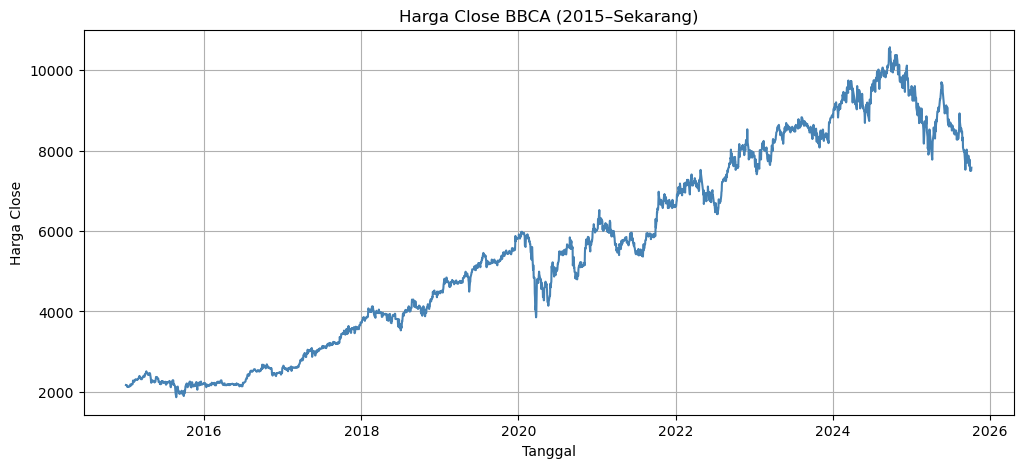

D:\Terminal\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Terminal\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
D:\Terminal\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2653
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -15602.238
Date:                Mon, 20 Oct 2025   AIC                          31210.475
Time:                        18:45:34   BIC                          31228.124
Sample:                             0   HQIC                         31216.863
                               - 2653                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3539      0.077      4.613      0.000       0.204       0.504
ma.L1         -0.4799      0.071     -6.780      0.000      -0.619      -0.341
sigma2      7543.7974    106.836     70.611      0.0

ValueError: Found input variables with inconsistent numbers of samples: [2652, 2653]

In [3]:
# ============================================================
# 🔹 FORECASTING HARGA CLOSE DENGAN ARIMA + RMSE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

# --- 1. Baca file Excel ---
file_path = r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\Data\Data_BBCA_2015_sampai_sekarang.xlsx"
data = pd.read_excel(file_path)

# --- 2. Cek kolom dan ubah kolom waktu ---
print("Kolom tersedia:", data.columns.tolist())

# Asumsikan kolom waktu = 'Price' dan kolom target = 'Close'
data['Price'] = pd.to_datetime(data['Price'], errors='coerce')
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')

# --- 3. Bersihkan data ---
data = data.dropna(subset=['Price', 'Close'])
data = data.set_index('Price')
data = data.loc['2015-01-01':]

# --- 4. Visualisasi awal ---
plt.figure(figsize=(12,5))
plt.plot(data['Close'], color='steelblue')
plt.title('Harga Close BBCA (2015–Sekarang)')
plt.xlabel('Tanggal')
plt.ylabel('Harga Close')
plt.grid(True)
plt.show()

# --- 5. Bangun model ARIMA ---
# (p,d,q) bisa disesuaikan — di sini contoh (1,1,1)
model = ARIMA(data['Close'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

# --- 6. Hitung RMSE (in-sample) ---
fitted_values = model_fit.fittedvalues
# Karena differencing (d=1), panjangnya sedikit lebih pendek
actual = data['Close'].iloc[1:]
rmse = np.sqrt(mean_squared_error(actual, fitted_values))
print(f"\n✅ RMSE (in-sample): {rmse:.2f}")

# --- 7. Forecast 30 langkah ke depan ---
forecast_steps = 30
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=data.index[-1], periods=forecast_steps+1, freq='D')[1:]

forecast_mean = forecast.predicted_mean
forecast_conf = forecast.conf_int()

# --- 8. Plot hasil forecast ---
plt.figure(figsize=(12,5))
plt.plot(data['Close'], label='Data Aktual', color='blue')
plt.plot(forecast_index, forecast_mean, label='Forecast (ARIMA)', color='red')
plt.fill_between(forecast_index,
                 forecast_conf['lower Close'],
                 forecast_conf['upper Close'],
                 color='pink', alpha=0.3)
plt.title(f'Forecasting Harga Close BBCA ({forecast_steps} Hari ke Depan)')
plt.xlabel('Tanggal')
plt.ylabel('Harga Close')
plt.legend()
plt.grid(True)
plt.show()

# --- 9. Simpan hasil ke file Excel ---
hasil_forecast = pd.DataFrame({
    'Tanggal': forecast_index,
    'Prediksi_Close': forecast_mean,
    'Lower_CI': forecast_conf['lower Close'],
    'Upper_CI': forecast_conf['upper Close']
})
hasil_forecast.to_excel('Forecast_ARIMA_Close_BBCA.xlsx', index=False)

print("✅ Forecast ARIMA selesai dan disimpan sebagai 'Forecast_ARIMA_Close_BBCA.xlsx'")


Kolom tersedia di file: ['Price', 'Close', 'High', 'Low', 'Open', 'Volume']


/tmp/ipython-input-3949102101.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Price'] = pd.to_datetime(data['Price'], errors='coerce')
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasti


===== 🔹 5 Nilai Residual Pertama 🔹 =====
Price
2015-01-02    2171.209473
2015-01-05      -2.121068
2015-01-06     -15.996108
2015-01-07       2.230602
2015-01-08     -24.979342
dtype: float64

===== 🔹 Statistik Residual 🔹 =====
count    2658.000000
mean        3.200905
std        96.590813
min      -697.749375
25%       -31.757336
50%         0.878154
75%        34.245033
max      2171.209473
dtype: float64


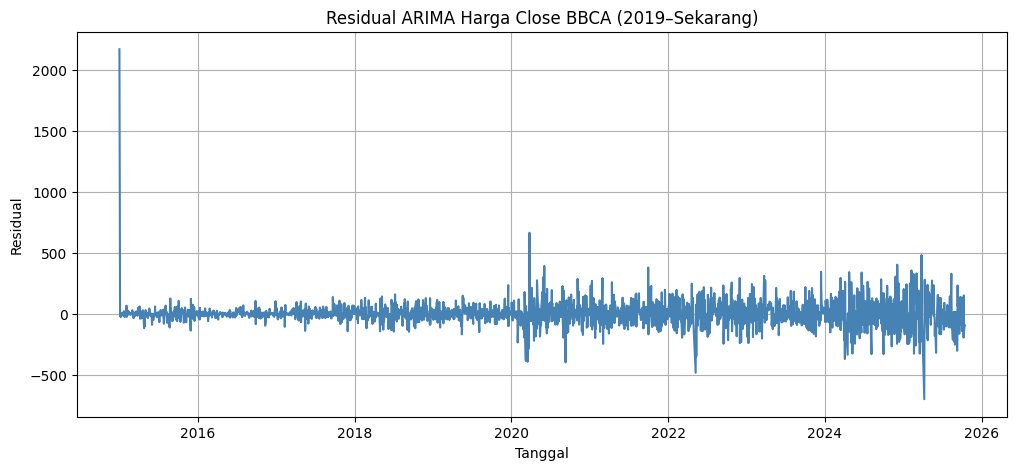


✅ Residual ARIMA berhasil disimpan ke file 'Residual_ARIMA_Close_BBCA.xlsx'


In [17]:
# 🔹 ARIMA untuk Harga Close BBCA
# 🔹 Periode: 2015 - Sekarang
# 🔹 Output: Residual (tampil, grafik, Excel)

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# --- 1. Baca file Excel ---
file_path = "Data_BBCA_2015_sampai_sekarang.xlsx"
data = pd.read_excel(file_path)

# --- 2. Cek kolom yang tersedia ---
print("Kolom tersedia di file:", data.columns.tolist())

# --- 3. Ubah kolom 'Price' jadi tanggal (karena 'Date' tidak ada) ---
data['Price'] = pd.to_datetime(data['Price'], errors='coerce')

# --- 4. Pastikan kolom 'Close' adalah numerik ---
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')

# --- 5. Hapus baris kosong atau invalid ---
data = data.dropna(subset=['Price', 'Close'])

# --- 6. Jadikan 'Price' sebagai index waktu ---
data = data.set_index('Price')

# --- 7. Filter data mulai 2019 sampai sekarang ---
data = data.loc['2015-01-01':]

# --- 8. Fit model ARIMA ---
model = ARIMA(data['Close'], order=(1,1,1))
model_fit = model.fit()

# --- 9. Ambil residual ---
residuals = model_fit.resid

# --- 10. Tampilkan sebagian hasil residual ---
print("\n===== 🔹 5 Nilai Residual Pertama 🔹 =====")
print(residuals.head())

print("\n===== 🔹 Statistik Residual 🔹 =====")
print(residuals.describe())

# --- 11. Plot residual ---
plt.figure(figsize=(12,5))
plt.plot(residuals, color='steelblue')
plt.title('Residual ARIMA Harga Close BBCA (2019–Sekarang)')
plt.xlabel('Tanggal')
plt.ylabel('Residual')
plt.grid(True)
plt.show()

# --- 12. Simpan residual ke file Excel ---
residuals_df = pd.DataFrame({
    'Tanggal': residuals.index,
    'Residual': residuals.values
})
residuals_df.to_excel('Residual_ARIMA_Close_BBCA.xlsx', index=False)

print("\n✅ Residual ARIMA berhasil disimpan ke file 'Residual_ARIMA_Close_BBCA.xlsx'")


/tmp/ipython-input-1257275620.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Price'] = pd.to_datetime(data['Price'], errors='coerce')
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasti

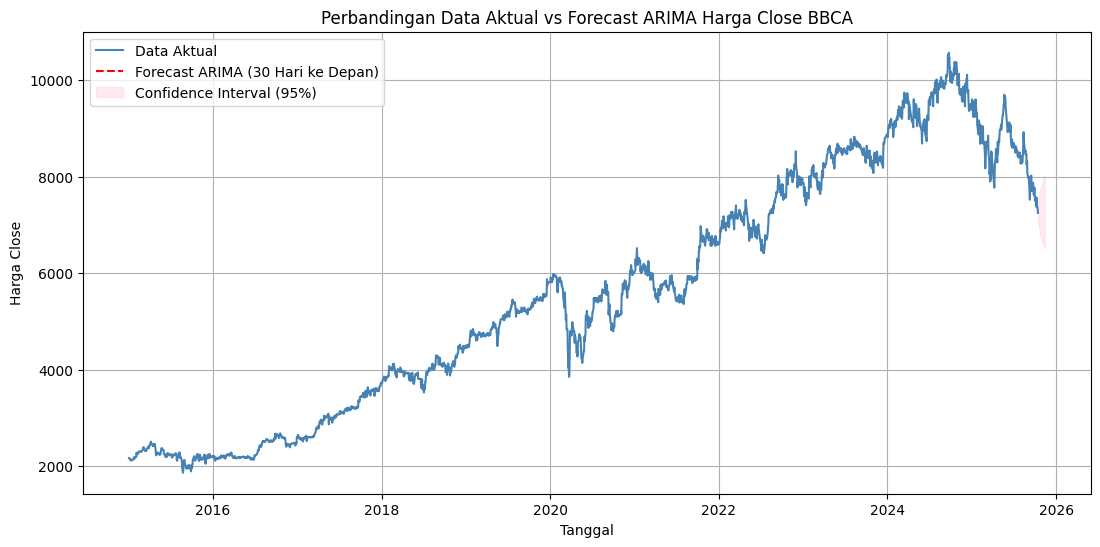

✅ Forecast ARIMA selesai dan grafik perbandingan berhasil ditampilkan.
📁 Hasil juga disimpan ke file: 'Forecast_ARIMA_Close_BBCA.xlsx'


In [21]:
# 🔹 FORECASTING HARGA CLOSE DENGAN ARIMA
# 🔹 + Grafik perbandingan data aktual vs hasil prediksi

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# --- 1. Baca file Excel ---
file_path = 'Data_BBCA_2015_sampai_sekarang.xlsx'
data = pd.read_excel(file_path)

# --- 2. Ubah kolom waktu dan bersihkan data ---
data['Price'] = pd.to_datetime(data['Price'], errors='coerce')
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')
data = data.dropna(subset=['Price', 'Close'])
data = data.set_index('Price')
data = data.loc['2015-01-01':]

# --- 3. Bangun model ARIMA ---
model = ARIMA(data['Close'], order=(1,1,1))
model_fit = model.fit()

# --- 4. Forecast 30 hari ke depan ---
forecast_steps = 30
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=data.index[-1], periods=forecast_steps+1, freq='D')[1:]
forecast_mean = forecast.predicted_mean
forecast_conf = forecast.conf_int()

# --- 5. Gabungkan data aktual & hasil forecast untuk perbandingan ---
forecast_series = pd.Series(forecast_mean, index=forecast_index)
combined = pd.concat([data['Close'], forecast_series], axis=0)
combined.name = 'Close'

# --- 6. Plot perbandingan ---
plt.figure(figsize=(13,6))
plt.plot(data['Close'], label='Data Aktual', color='steelblue')
plt.plot(forecast_series, label='Forecast ARIMA (30 Hari ke Depan)', color='red', linestyle='--')
plt.fill_between(forecast_index,
                 forecast_conf['lower Close'],
                 forecast_conf['upper Close'],
                 color='pink', alpha=0.3, label='Confidence Interval (95%)')

plt.title('Perbandingan Data Aktual vs Forecast ARIMA Harga Close BBCA')
plt.xlabel('Tanggal')
plt.ylabel('Harga Close')
plt.legend()
plt.grid(True)
plt.show()

# --- 7. Simpan hasil forecast ke Excel ---
hasil_forecast = pd.DataFrame({
    'Tanggal': forecast_index,
    'Prediksi_Close': forecast_mean,
    'Lower_CI': forecast_conf['lower Close'],
    'Upper_CI': forecast_conf['upper Close']
})
hasil_forecast.to_excel('Forecast_ARIMA_Close_BBCA.xlsx', index=False)

print("✅ Forecast ARIMA selesai dan grafik perbandingan berhasil ditampilkan.")
print("📁 Hasil juga disimpan ke file: 'Forecast_ARIMA_Close_BBCA.xlsx'")


forecasting arima lstm

Kolom Data Harga: ['Price', 'Close', 'High', 'Low', 'Open', 'Volume']
Kolom Residual: ['Tanggal', 'Residual']
Epoch 1/50


/tmp/ipython-input-1348802920.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data_harga['Price'] = pd.to_datetime(data_harga['Price'], errors='coerce')
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - loss: 0.0233 - val_loss: 0.0017
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 4.4316e-04 - val_loss: 9.2631e-04
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 4.2849e-04 - val_loss: 8.2296e-04
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 3.8518e-04 - val_loss: 6.9915e-04
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - loss: 3.5286e-04 - val_loss: 6.2964e-04
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 3.6859e-04 - val_loss: 8.1594e-04
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - loss: 4.3382e-04 - val_loss: 5.9894e-04
Epoch 8/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - loss: 3.4362e-04 - val_loss: 6.1982e-04
Epoch 9/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 3.3208e-04 - val_loss: 5.4811e-04
Epoch 10/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - loss: 3.2946e-04 - val_loss: 4.9422e-04
Epoch 11/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 3.5775e-04 - val_loss: 5.048

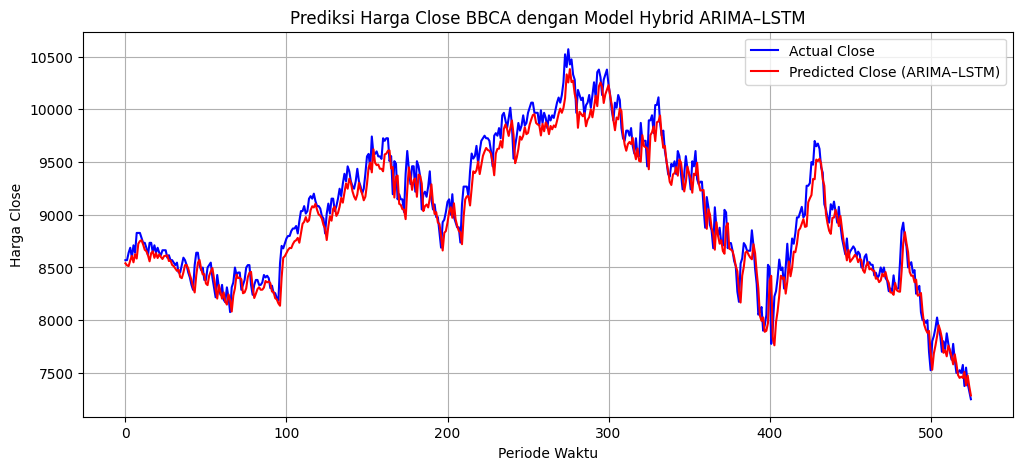

✅ Prediksi selesai dan disimpan sebagai 'Hasil_Prediksi_ARIMA_LSTM_BBCA.xlsx'


In [18]:
# 🔹 HYBRID MODEL: ARIMA–LSTM untuk Prediksi Harga Close BBCA
# 🔹 Fitur Input : Close, Low, Open, Volume, Residual_ARIMA
# 🔹 Target      : Close

# --- 1. Import Library ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# --- 2. Baca File Data Harga dan Residual ---
data_harga = pd.read_excel('Data_BBCA_2015_sampai_sekarang.xlsx')
data_residual = pd.read_excel('Residual_ARIMA_Close_BBCA.xlsx')

print("Kolom Data Harga:", data_harga.columns.tolist())
print("Kolom Residual:", data_residual.columns.tolist())

# --- 3. Ubah kolom waktu dan gabungkan ---
data_harga['Price'] = pd.to_datetime(data_harga['Price'], errors='coerce')
data_residual['Tanggal'] = pd.to_datetime(data_residual['Tanggal'], errors='coerce')

# Sinkronisasi berdasarkan tanggal
data = pd.merge(data_harga, data_residual, left_on='Price', right_on='Tanggal', how='inner')

# --- 4. Ambil kolom yang dibutuhkan ---
df = data[['Close', 'Low', 'Open', 'Volume', 'Residual']].copy()
df = df.dropna().reset_index(drop=True)

# --- 5. Normalisasi ---
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df)

# --- 6. Membuat dataset time-series untuk LSTM ---
def create_dataset(dataset, time_step=30):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:i + time_step, :])
        y.append(dataset[i + time_step, 0])  # kolom 0 = Close
    return np.array(X), np.array(y)

time_step = 30
X, y = create_dataset(scaled, time_step)

# --- 7. Split train dan test ---
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# --- 8. Bangun model LSTM ---
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(time_step, X.shape[2])),
    Dropout(0.2),
    LSTM(64),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# --- 9. Latih model ---
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# --- 10. Prediksi ---
y_pred = model.predict(X_test)

# --- 11. Kembalikan ke skala asli ---
# Buat dummy array agar inverse_transform bisa dijalankan
pred_full = np.zeros((len(y_pred), scaled.shape[1]))
pred_full[:, 0] = y_pred.flatten()
predicted_close = scaler.inverse_transform(pred_full)[:, 0]

actual_full = np.zeros((len(y_test), scaled.shape[1]))
actual_full[:, 0] = y_test.flatten()
actual_close = scaler.inverse_transform(actual_full)[:, 0]

# --- 12. Visualisasi ---
plt.figure(figsize=(12,5))
plt.plot(actual_close, label='Actual Close', color='blue')
plt.plot(predicted_close, label='Predicted Close (ARIMA–LSTM)', color='red')
plt.title('Prediksi Harga Close BBCA dengan Model Hybrid ARIMA–LSTM')
plt.xlabel('Periode Waktu')
plt.ylabel('Harga Close')
plt.legend()
plt.grid(True)
plt.show()

# --- 13. Simpan hasil ke Excel ---
hasil = pd.DataFrame({
    'Actual_Close': actual_close,
    'Predicted_Close': predicted_close
})
hasil.to_excel('Hasil_Prediksi_ARIMA_LSTM_BBCA.xlsx', index=False)

print("✅ Prediksi selesai dan disimpan sebagai 'Hasil_Prediksi_ARIMA_LSTM_BBCA.xlsx'")


ANALISIS SENTIMEN
